#### 1-PreProcessing

In [62]:
import pandas as pd
import numpy as np

df = pd.read_csv("Dataset/Life_Expectancy_Data.csv")
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [63]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df["Status"] = le.fit_transform(df["Status"])
df = df.drop(columns=['Country'])

num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]



In [64]:
from sklearn.model_selection import train_test_split

y = df["Life expectancy"]
X = df.drop("Life expectancy", axis=1)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=2)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=2)

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#### 2- Simple Neural Network

In [66]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

input_dim = X_train_t.shape[1]

In [67]:
class Model1(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(input_dim, 16)
        self.out = nn.Linear(16, 1)
    def forward(self, x):
        x = torch.relu(self.hidden(x))
        return self.out(x)

class Model2(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(input_dim, 32)
        self.hidden2 = nn.Linear(32, 16)
        self.out = nn.Linear(16, 1)
    def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = torch.relu(self.hidden2(x))
        return self.out(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model1 = Model1()
model2 = Model2()

params_model1 = count_params(model1)
params_model2 = count_params(model2)

criterion = nn.MSELoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

def train_model(model, optimizer):
    train_losses = []
    val_losses = []
    for epoch in range(100):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        with torch.no_grad():
            val_loss = 0
            for xb, yb in val_loader:
                val_loss += criterion(model(xb), yb).item()
            val_losses.append(val_loss / len(val_loader))
    return train_losses, val_losses

def evaluate(model):
    model.eval()
    preds = []
    reals = []
    with torch.no_grad():
        for xb, yb in test_loader:
            p = model(xb)
            preds.append(p)
            reals.append(yb)
    preds = torch.cat(preds).numpy()
    reals = torch.cat(reals).numpy()
    mse = np.mean((preds - reals)**2)
    rmse = np.sqrt(mse)
    ss_res = np.sum((reals - preds)**2)
    ss_tot = np.sum((reals - np.mean(reals))**2)
    r2 = 1 - ss_res/ss_tot
    return mse, rmse, r2

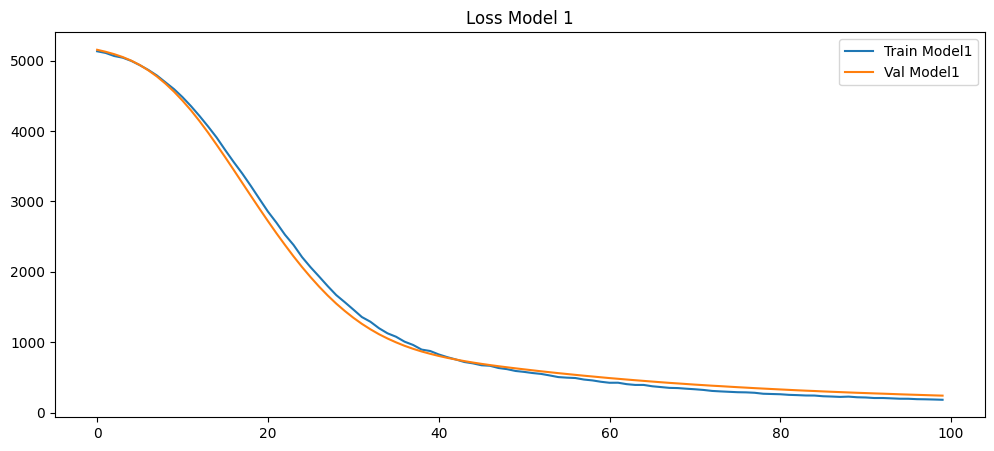

In [68]:
train1, val1 = train_model(model1, optimizer1)

mse1, rmse1, r2_1 = evaluate(model1)

plt.figure(figsize=(12,5))
plt.plot(train1, label="Train Model1")
plt.plot(val1, label="Val Model1")
plt.legend()
plt.title("Loss Model 1")
plt.show()

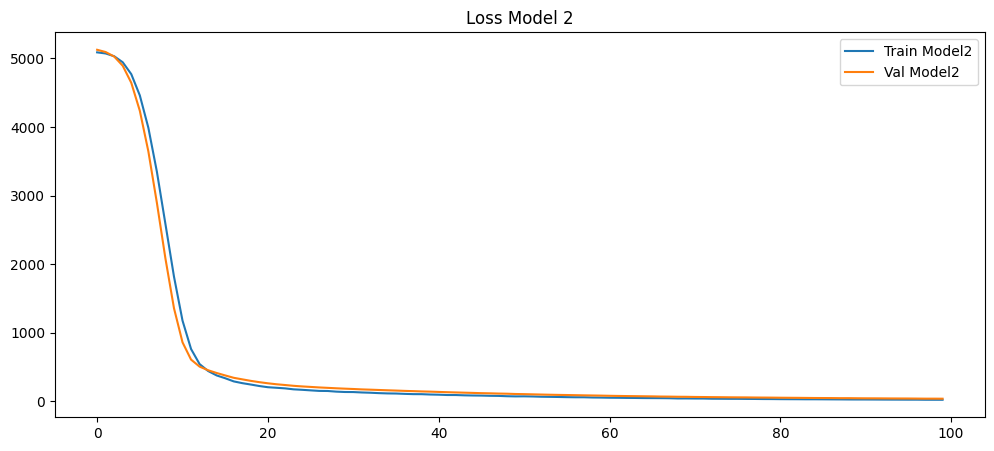

(353,
 1217,
 np.float32(215.52701),
 np.float32(14.680839),
 np.float32(-7.7003107),
 np.float32(31.980688),
 np.float32(5.655147),
 np.float32(-0.29098403))

In [69]:
train2, val2 = train_model(model2, optimizer2)
mse2, rmse2, r2_2 = evaluate(model2)

plt.figure(figsize=(12,5))
plt.plot(train2, label="Train Model2")
plt.plot(val2, label="Val Model2")
plt.legend()
plt.title("Loss Model 2")
plt.show()

params_model1, params_model2, mse1, rmse1, r2_1, mse2, rmse2, r2_2